# Tester_branch에서 성능 확인 진행

In [1]:
# 라이브러리 및 데이터 불러오기

import warnings
warnings.filterwarnings('ignore')

import pandas as pd
from sklearn.datasets import load_wine

from sklearn.model_selection import train_test_split, GridSearchCV

import matplotlib.pyplot as plt

wine = load_wine()

''' 데이터 코드를 작성해주세요 '''

# feature로 사용할 데이터에서는 'target' 컬럼을 drop합니다.
# target은 'target' 컬럼만을 대상으로 합니다.
# X, y 데이터를 test size는 0.2, random_state 값은 42로 하여 train 데이터와 test 데이터로 분할합니다.
wine_df = pd.DataFrame(data=wine.data, columns=wine.feature_names)
wine_df['target'] = wine.target
X = wine_df.drop(columns='target')
y = wine_df['target']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# DT 모델링 성능

Best parameters:  {'criterion': 'gini', 'max_depth': 3, 'min_samples_leaf': 1, 'min_samples_split': 2}
Best accuracy:  0.9224137931034484


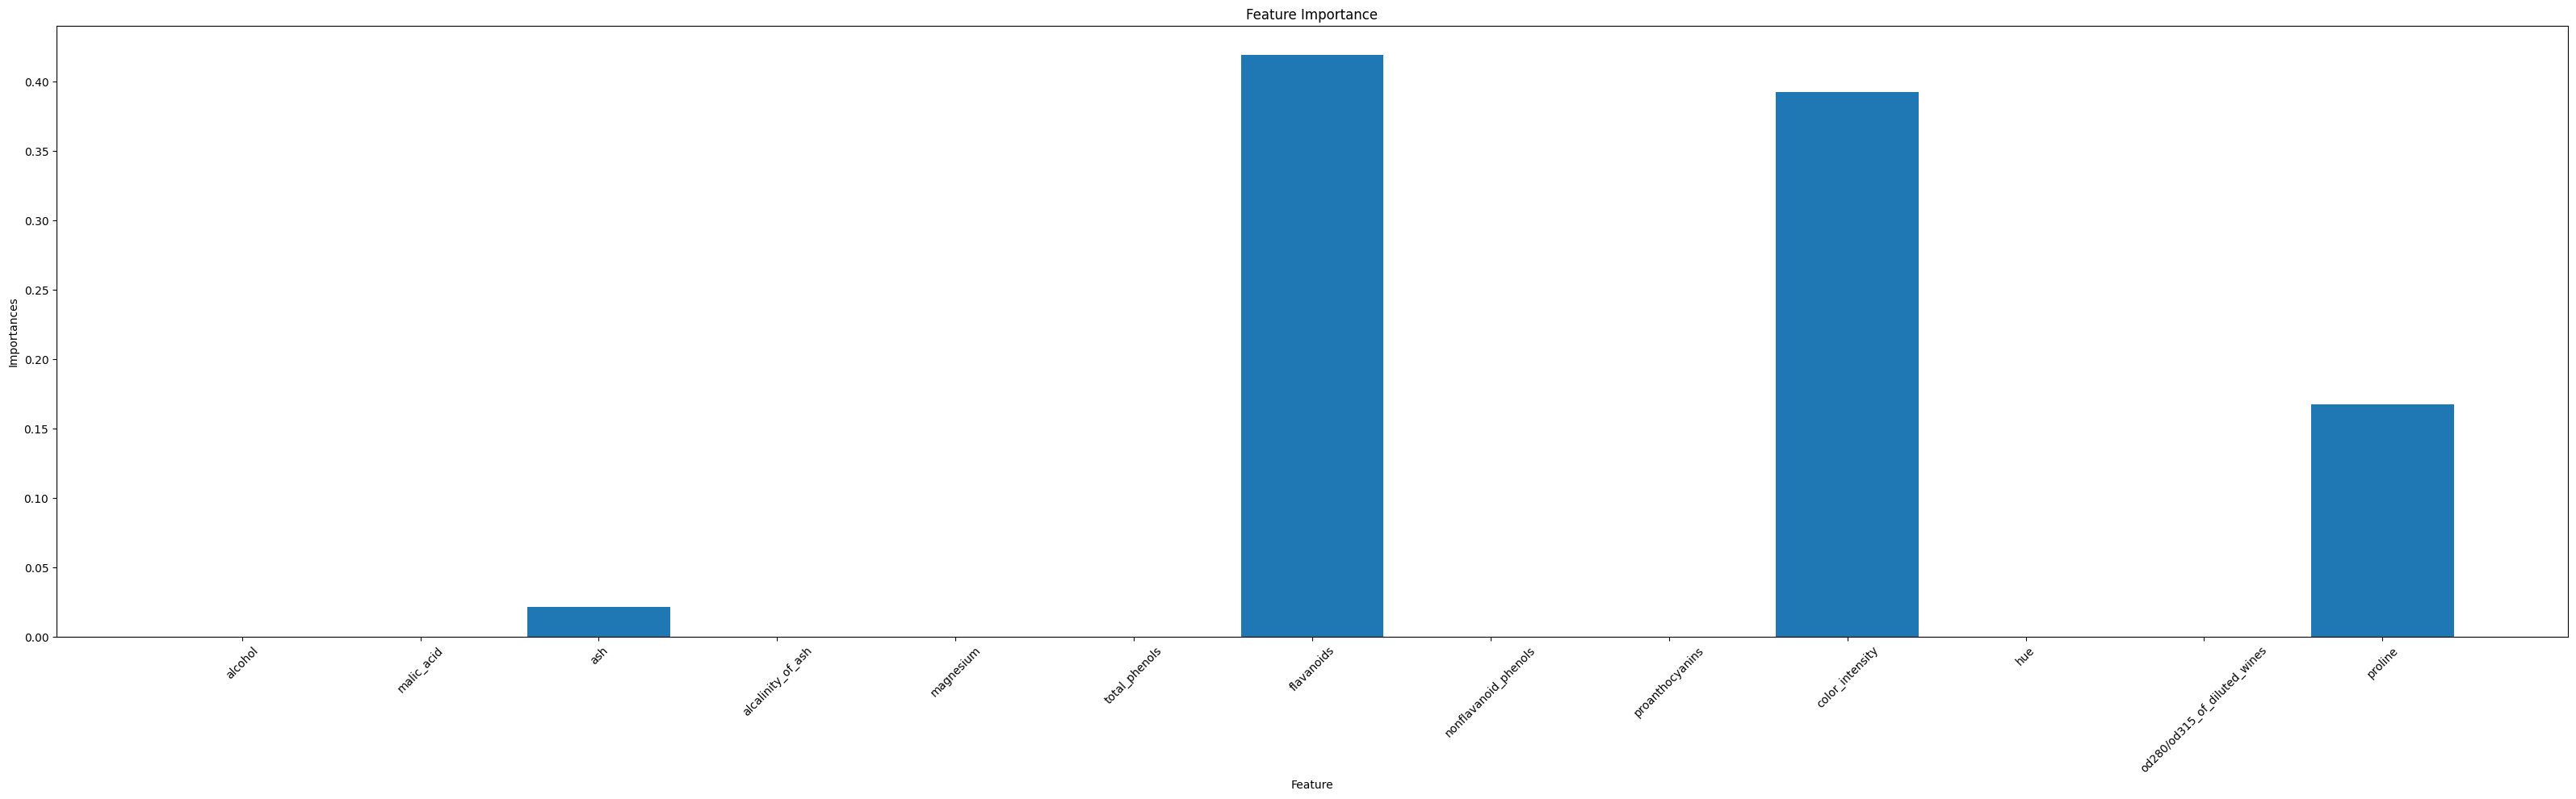

In [12]:
''' 코드를 작성해주세요 '''
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV
import seaborn as sns

param_grid = {
    'criterion': ['gini', 'entropy'],
    'max_depth': [2, 3, 4, 5],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

dt = DecisionTreeClassifier(random_state=42)
gridsearch_dt = GridSearchCV(dt, param_grid, cv=5, scoring='accuracy', n_jobs=-1)
gridsearch_dt.fit(X_train, y_train)
print('Best parameters: ', gridsearch_dt.best_params_)
print('Best accuracy: ', gridsearch_dt.best_score_)

importances = gridsearch_dt.best_estimator_.feature_importances_
features = X.columns
plt.figure(figsize=(32, 10))
plt.title("Feature Importance")
plt.bar(features, importances)
plt.xticks(rotation=45)
plt.xlabel("Feature")
plt.ylabel("Importances")
plt.tight_layout()
plt.show()

<img src="../참고이미지/Git/DT_Modeling.png" width="80%">

# XGB 모델링 성능

Best parameters:  {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 100}
Best accuracy:  0.9576354679802955


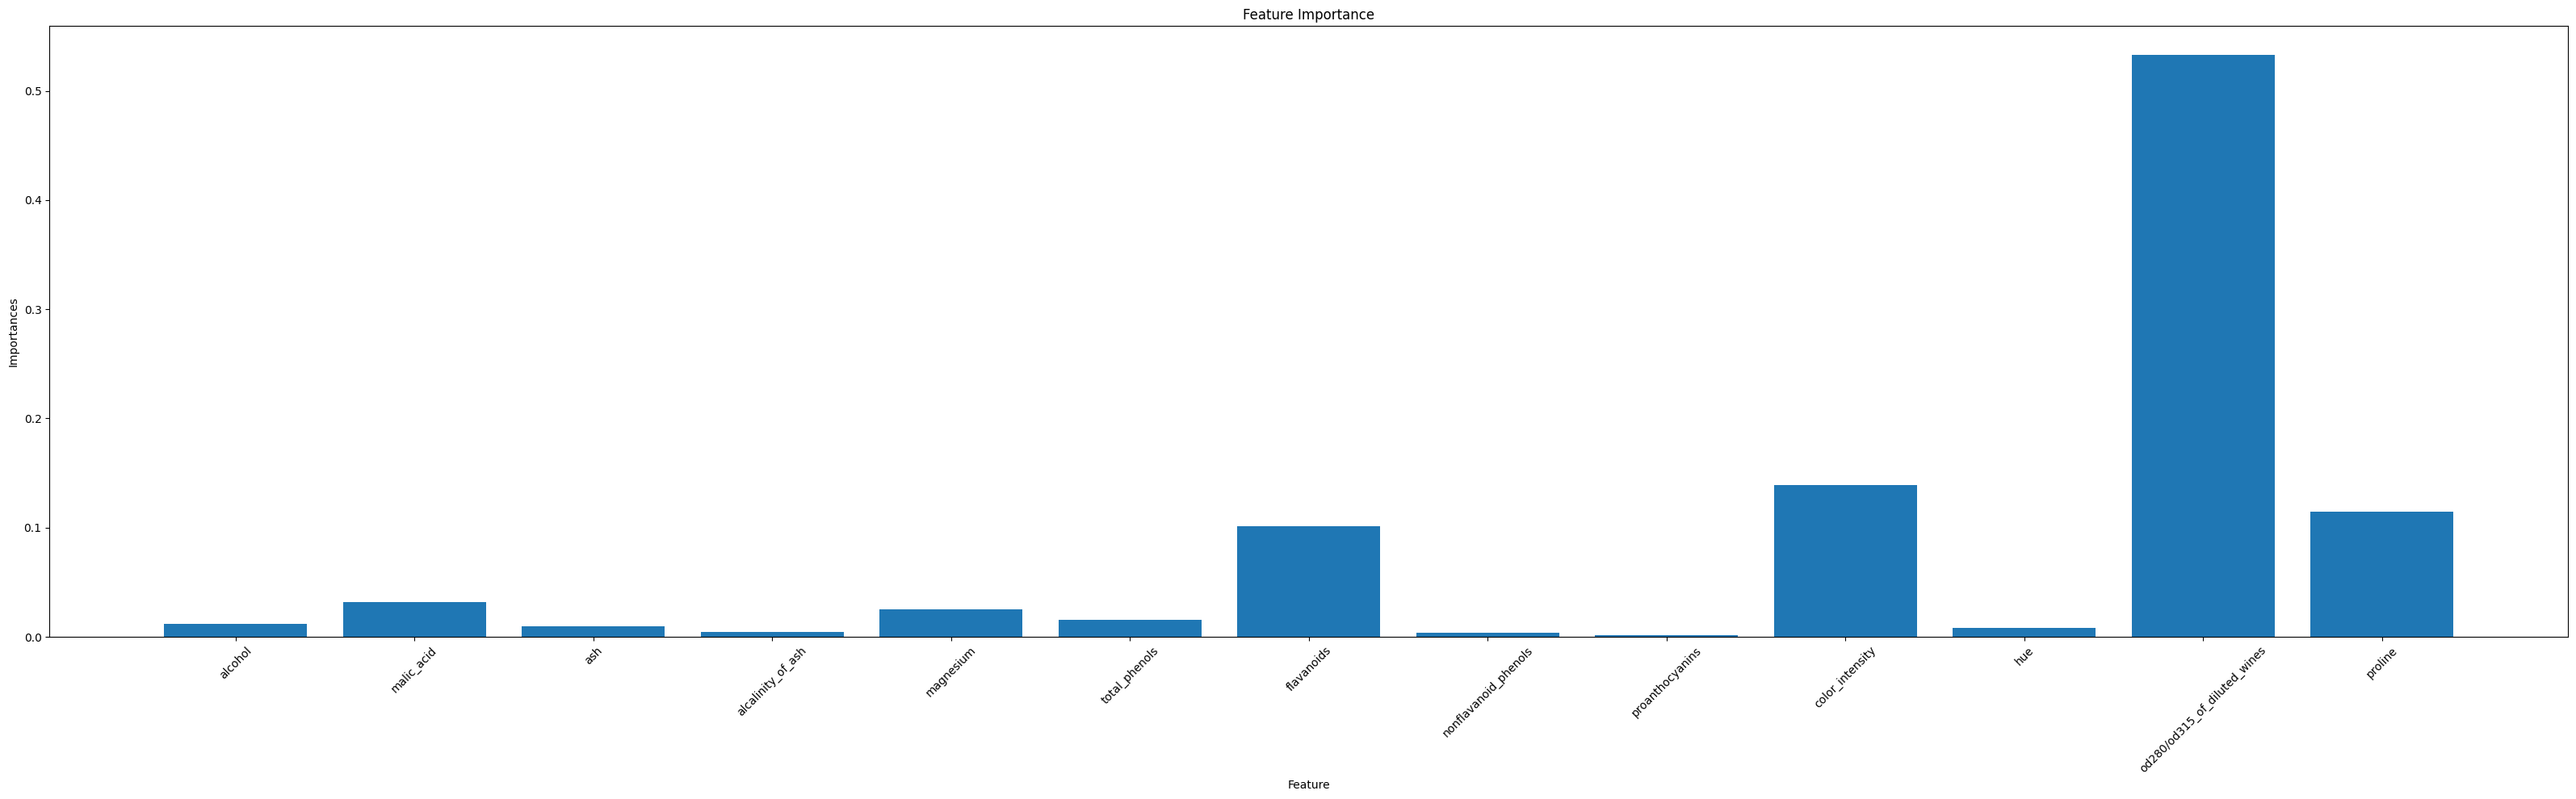

In [13]:
''' 코드를 작성해주세요 '''
from xgboost import XGBClassifier
from sklearn.model_selection import GridSearchCV

param_grid = {
    'max_depth': [3, 5, 7, 9, 15],
    'learning_rate': [0.1, 0.01, 0.001],
    'n_estimators': [50, 100, 200, 300]
}

clf = XGBClassifier(random_state=42)
gridsearch_xgb = GridSearchCV(clf, param_grid, cv=5, scoring='accuracy', n_jobs=-1)
gridsearch_xgb.fit(X_train, y_train)
print('Best parameters: ', gridsearch_xgb.best_params_)
print('Best accuracy: ', gridsearch_xgb.best_score_)

importances = gridsearch_xgb.best_estimator_.feature_importances_
features = X.columns
plt.figure(figsize=(32, 10))
plt.title("Feature Importance")
plt.bar(features, importances)
plt.xticks(rotation=45)
plt.xlabel("Feature")
plt.ylabel("Importances")
plt.tight_layout()
plt.show()

<img src="../참고이미지/Git/XGB_Modeling.png" width="80%">`

# 성능 비교 시각화

========== DT 성능 확인 ==========
DT accuracy :  0.9224137931034484
              precision    recall  f1-score   support

           0       1.00      0.93      0.96        14
           1       0.88      1.00      0.93        14
           2       1.00      0.88      0.93         8

    accuracy                           0.94        36
   macro avg       0.96      0.93      0.94        36
weighted avg       0.95      0.94      0.94        36

========== XGB 성능 확인 ==========
XGB accuracy :  0.9576354679802955
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        14
           1       0.93      1.00      0.97        14
           2       1.00      0.88      0.93         8

    accuracy                           0.97        36
   macro avg       0.98      0.96      0.97        36
weighted avg       0.97      0.97      0.97        36



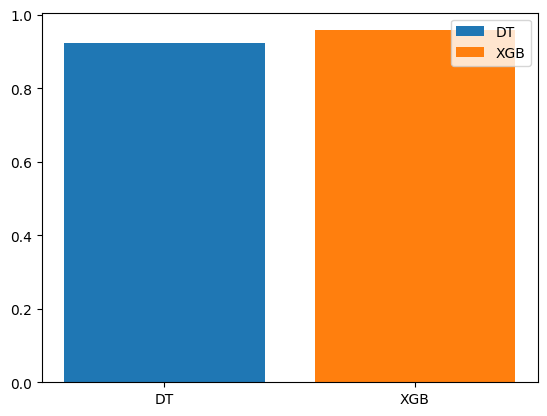

In [23]:
''' 코드를 작성해주세요 '''
from sklearn.metrics import classification_report
print('='*10, 'DT 성능 확인', '='*10)
print('DT accuracy : ', gridsearch_dt.best_score_)
y_pred_dt = gridsearch_dt.predict(X_test)
print(classification_report(y_test, y_pred_dt))

print('='*10, 'XGB 성능 확인', '='*10)
print('XGB accuracy : ', gridsearch_xgb.best_score_)
y_pred_xgb = gridsearch_xgb.predict(X_test)
print(classification_report(y_test, y_pred_xgb))

import numpy as np
models = ['DT', 'XGB']
scores = [gridsearch_dt.best_score_, gridsearch_xgb.best_score_]

plt.bar(models[0], scores[0], label='DT')
plt.bar(models[1], scores[1], label='XGB')
plt.legend()
plt.show()

<img src="../참고이미지/Git/성능_비교_시각화.png" width="40%">